# Notebook 01: Traditional Data Science & Machine Learning

**AI Foundation**

---

### What You Will Learn Today

By the end of this notebook, you will be able to:

1. Understand what **Data Science** and **Machine Learning** are
2. Know the types of data used in AI/ML
3. Use **NumPy** for numerical computing
4. Understand the **3 core ML problem types**
5. Follow the **7 steps of traditional ML**
6. Build your **first ML model** (Linear Regression) with **Scikit-Learn**
7. Interpret model results and make predictions

---

## Part 1: What is Data Science & Machine Learning?

**Data Science** = Using data to extract insights, find patterns, and make decisions.

**Machine Learning** = Using data to answer questions - the computer *learns* patterns from data instead of being explicitly programmed.

...

> **Key Insight:** In traditional programming, we write rules. In ML, the machine learns the rules from data.

### Types of Data in AI/ML

| # | Data Type | Examples | Used In |
|---|-----------|----------|---------|
| 1 | **Historical / Tabular** | CSV, SQL, Excel (rows & columns) | Traditional DS & ML |
| 2 | **Image** | PNG, JPG, DICOM | Computer Vision (CNNs) |
| 3 | **Text** | Documents, Tweets, Logs | NLP, LLMs |
| 4 | **Audio** | WAV, MP3, Speech | Speech Recognition |
| 5 | **Video** | MP4, Streams | Action Recognition |

...
> **This notebook focuses on Tabular/Historical Data** - the foundation of traditional DS & ML.

---

## Part 2: The Python Toolkit

These are the 4 essential libraries for traditional Data Science & ML:

| Library | Purpose | Website |
|---------|---------|--------|
| **NumPy** | Numerical computing (arrays, math) | [numpy.org](https://numpy.org) |
| **Pandas** | Data manipulation (DataFrames) | [pandas.pydata.org](https://pandas.pydata.org) |
| **Matplotlib** | Data visualization (plots, charts) | [matplotlib.org](https://matplotlib.org) |
| **Scikit-Learn** | ML algorithms & model building | [scikit-learn.org](https://scikit-learn.org) |

**Alternatives for Deep Learning:** PyTorch, TensorFlow, Keras

...
> Today we'll use **NumPy** (for data) and **Scikit-Learn** (for ML).

---

## Part 3: NumPy - Numerical Python

NumPy is the **foundation** of scientific computing in Python.

### Why NumPy instead of Python Lists?

- **Faster** - C-optimized, vectorized operations
- **Memory Efficient** - contiguous memory storage
- **Broadcasting** - element-wise math without loops
- **Foundation** - Pandas, Scikit-Learn, TensorFlow all built on NumPy

In [1]:
import numpy as np

print(f"NumPy version: {np.__version__}")

NumPy version: 2.4.2


### Creating Arrays

In [2]:
# Creating a 1D array
arr = np.array([2, 4, 6, 8])

print("Array:", arr)

Array: [2 4 6 8]


### Array Properties

Every NumPy array has key attributes:

In [3]:
print(f"Shape: {arr.shape}")   # Dimensions -> (4,) means 4 elements
print(f"Ndim:  {arr.ndim}")    # Number of dimensions -> 1 (it's a 1D array)
print(f"Dtype: {arr.dtype}")   # Data type -> int64 (64-bit integer)
print(f"Size:  {arr.size}")    # Total elements -> 4

Shape: (4,)
Ndim:  1
Dtype: int64
Size:  4


### Broadcasting - The Power of NumPy

NumPy can perform **element-wise operations** without writing any loops. This is called **broadcasting**.

In [4]:
# Broadcasting: add 5 to every element (no loop needed!)
result = arr + 5

print(f"Original: {arr}")
print(f"arr + 5:  {result}")

Original: [2 4 6 8]
arr + 5:  [ 7  9 11 13]


In [5]:
# More operations
print(f"arr * 2:  {arr * 2}")     # Multiply each element by 2
print(f"arr ** 2: {arr ** 2}")    # Square each element
print(f"Sum:      {arr.sum()}")   # Sum of all elements
print(f"Mean:     {arr.mean()}")  # Average

arr * 2:  [ 4  8 12 16]
arr ** 2: [ 4 16 36 64]
Sum:      20
Mean:     5.0


> **Why this matters:** In ML, our data is stored as NumPy arrays. Training a model involves millions of mathematical operations - NumPy makes this fast and efficient.

---

## Part 4: Types of ML Problems

Traditional ML solves 3 types of problems:

| # | Problem Type | What It Does | Example |
|---|-------------|-------------|--------|
| 1 | **Regression** | Predicts a continuous number | House price, Temperature |
| 2 | **Classification** | Predicts a category/label | Spam or Not Spam, Disease Diagnosis |
| 3 | **Clustering** | Groups similar data (no labels) | Customer Segmentation |

...

> **Today we will solve a Regression problem** using Linear Regression.

---

## Part 5: The 7 Steps of Traditional ML

```
1. Gather Data           -> Collect the dataset
2. Prepare Data          -> Clean, reshape, split
3. Choose a Model        -> Pick the right algorithm
4. Train the Model       -> model.fit(X, y)
5. Evaluate the Model    -> model.score(X, y)
6. Hyperparameter Tuning -> Optimize for best performance (most important!)
7. Make Predictions      -> model.predict(new_data)
```

...

> **ML is just: using data to answer questions.** These 7 steps give you a structured approach.

Let's apply all 7 steps now! 

---

## Part 6: Building Your First ML Model - Linear Regression

### The Problem

We have some (x, y) data points. We want the machine to **learn the relationship** between x and y, so it can predict y for any new x.

| x  | y  |
|----|----|
| -1 | -3 |
|  0 |  1 |
|  1 |  1 |
|  2 |  3 |
|  3 |  5 |
|  4 |  7 |

**Question:** If x = 10, what is y?

### The Math Behind It

Linear Regression finds the best-fit line:

```
y = b₀ + b₁ · x       (Simple Linear Regression)
y = b₀ + b₁x₁ + b₂x₂ + ...  (Multiple Linear Regression)
```

Also written as: **y = mx + c** (slope-intercept form)

- **b₀** = Intercept (where the line crosses the y-axis)
- **b₁** = Slope (how much y changes when x increases by 1)

### Step 1 & 2: Gather & Prepare Data

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [7]:
# Step 1 & 2: Gather and Prepare Data

# Features (input) - must be 2D for scikit-learn
X = np.array([-1, 0, 1, 2, 3, 4], dtype=float).reshape(-1, 1)

# Target (output) - stays 1D
y = np.array([-3, 1, 1, 3, 5, 7], dtype=float)

print(f"X shape: {X.shape}")  # (6, 1) - 6 samples, 1 feature
print(f"y shape: {y.shape}")  # (6,)  - 6 target values

X shape: (6, 1)
y shape: (6,)


> **Why `.reshape(-1, 1)`?**
>
> Scikit-learn's `.fit()` method expects X to be **2D** (rows = samples, columns = features).
>
> - `[-1, 0, 1, 2, 3, 4]` -> shape `(6,)` - this is 1D 
> - `.reshape(-1, 1)` converts it to shape `(6, 1)` - now it's 2D 
>
> The `-1` means "figure out this dimension automatically."

In [8]:
# See the difference: 1D vs 2D
arr_1d = np.array([-1, 0, 1, 2, 3, 4])          # shape: (6,)
arr_2d = arr_1d.reshape(-1, 1)                  # shape: (6, 1)

print("1D array:")
print(arr_1d)
print(f"Shape: {arr_1d.shape}\n")

print("2D array (after reshape):")
print(arr_2d)
print(f"Shape: {arr_2d.shape}")

1D array:
[-1  0  1  2  3  4]
Shape: (6,)

2D array (after reshape):
[[-1]
 [ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]]
Shape: (6, 1)


### Step 3: Choose a Model

In [9]:
# Step 3: Choose a Model
model = LinearRegression()

print(f"Model: {model}")
print("Model created - not trained yet!")

Model: LinearRegression()
Model created - not trained yet!


### Step 4: Train the Model

In [10]:
# Step 4: Train the Model
# .fit() learns the relationship between X and y
model.fit(X, y)

print("Model trained! It has now learned the pattern from our data.")

Model trained! It has now learned the pattern from our data.


### Step 5: Evaluate the Model

In [11]:
# Step 5: Evaluate the Model
# .score() returns the R2 score (0 to 1, higher = better)
r2_score = model.score(X, y)

print(f"R2 Score: {r2_score:.4f}")
print(f"\nInterpretation: The model explains {r2_score*100:.1f}% of the variance in y.")
print("   (A perfect model would have R2 = 1.0)")

R2 Score: 0.9540

Interpretation: The model explains 95.4% of the variance in y.
   (A perfect model would have R2 = 1.0)


> **Step 6: Hyperparameter Tuning** — Linear Regression has no major hyperparameters to tune. For more complex models (Random Forest, Neural Networks), this step becomes the *most important*. We'll cover this in future notebooks.

### Step 7: Make Predictions

In [12]:
# Step 7: Make Predictions
x_new = 10
prediction = model.predict([[x_new]])

print(f"Prediction: When x = {x_new}, y ~ {prediction[0]:.2f}")

Prediction: When x = 10, y ~ 17.88


---

## Part 7: Understanding What the Model Learned

After training, the model stores the learned parameters:

In [13]:
# The learned equation: y = b0 + b1 . x

b1 = model.coef_[0]        # Slope
b0 = model.intercept_       # Intercept

print(f"Slope (b1):     {b1:.4f}")
print(f"Intercept (b0): {b0:.4f}")
print(f"\nLearned Equation: y = {b0:.4f} + {b1:.4f} . x")

Slope (b1):     1.8286
Intercept (b0): -0.4095

Learned Equation: y = -0.4095 + 1.8286 . x


### Verify the Prediction Manually

Let's verify by plugging x = 10 into the learned equation:

In [14]:
# Manual verification: y = b0 + b1 . x
x_test = 10
y_manual = b0 + b1 * x_test
y_model  = model.predict([[x_test]])[0]

print(f"Manual calculation: y = {b0:.4f} + {b1:.4f} . {x_test} = {y_manual:.4f}")
print(f"model.predict():   y = {y_model:.4f}")
print(f"\nThey match! The model is just using the equation it learned.")

Manual calculation: y = -0.4095 + 1.8286 . 10 = 17.8762
model.predict():   y = 17.8762

They match! The model is just using the equation it learned.


---

## Part 8: Bonus - Visualize the Results

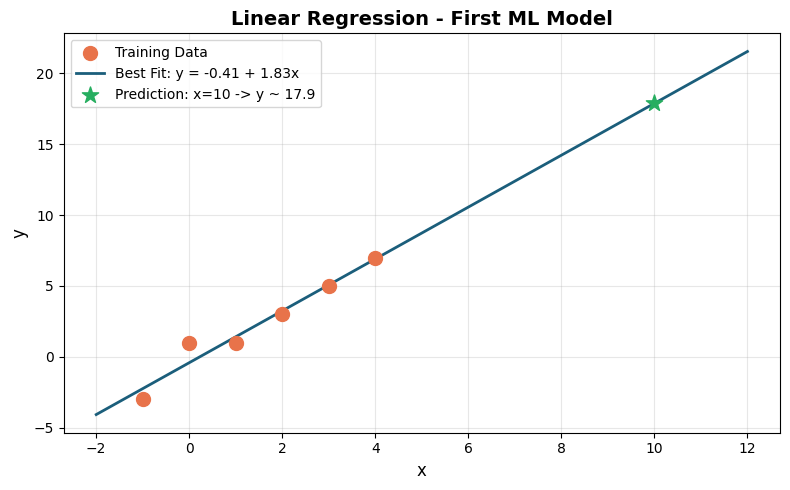

In [18]:
import matplotlib.pyplot as plt

# Generate predictions for the line
X_line = np.linspace(-2, 12, 100).reshape(-1, 1)
y_line = model.predict(X_line)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='#E8734A', s=100, zorder=5, label='Training Data')
plt.plot(X_line, y_line, color='#1B5E7B', linewidth=2, label=f'Best Fit: y = {b0:.2f} + {b1:.2f}x')
plt.scatter([10], [y_model], color='#27AE60', s=150, marker='*', zorder=5, label=f'Prediction: x=10 -> y ~ {y_model:.1f}')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Linear Regression - First ML Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Key Takeaways

| Concept | What You Learned |
|---------|------------------|
| **Data Science** | Using data to extract insights and make decisions |
| **Machine Learning** | Using data to answer questions -> the machine learns the rules |
| **Traditional ML** | Works primarily with tabular/historical data |
| **NumPy** | Fast numerical computing with arrays (foundation of ML in Python) |
| **7 Steps of ML** | Gather -> Prepare -> Choose -> Train -> Evaluate -> Tune -> Predict |
| **Linear Regression** | Finds the best-fit line: y = b0 + b1 . x |
| **R² Score** | Measures model performance (0 to 1, higher = better) |
| **model.coef_** | The learned slope (how much y changes per unit x) |
| **model.intercept_** | The learned intercept (y when x = 0) |

---

## Practice Exercises

Try these on your own:

1. **Change the data** - Create your own X and y arrays and train a new model
2. **Predict multiple values** - Use `model.predict([[5], [15], [20]])` to predict y for multiple x values
3. **Explore NumPy** - Try `np.zeros(5)`, `np.ones((3,3))`, `np.arange(0, 10, 2)`
4. **Break it on purpose** - What happens if you forget `.reshape(-1, 1)`?

---

**Next Notebook:** NumPy, Pandas, EDA (Exploratory Data Analysis) & More ML Algorithms

In [16]:
# Exercise Space - Try your experiments here!

